### This is a simple notebook to build and visualize decision trees.  
It accompanies Chapter 2 of the book.  
Copyright: Viviana Acquaviva (2023)  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)   
Some visualization-inspiration credits:
https://towardsdatascience.com/scikit-learn-decision-trees-explained-803f3812290d  
https://medium.com/@rnbrown/creating-and-visualizing-decision-trees-with-python-f8e8fa394176  
Modifications by Aaron Romanowsky

In [91]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd #new!
from sklearn.tree import DecisionTreeClassifier #how methods are imported 
from sklearn import tree
from sklearn import metrics #this will give us access to evaluation metrics
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [92]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('xtick.major', size=10, width=1.2)
plt.rc('ytick.major', size=10, width=1.2)
plt.rc('figure', figsize=[12,8])

In [93]:
#Here are some packages for visualization purposes only - this cell can be skipped if troublesome

from io import StringIO
from IPython.display import Image  
import pydotplus # may need to install

from sklearn.tree import export_graphviz #you can just use this if the other lines give trouble

### We use a selection of data from [the Planet Habitability Lab](https://phl.upr.edu/projects/habitable-exoplanets-catalog).

### We begin by reading in the data set using pandas.

In [94]:
LearningSet0 = pd.read_csv('HPLearningSet.csv')

In [95]:
LearningSet0

,Unnamed: 0,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,0,Kepler-736 b,0.86,3.601472,0.043718,0
1,1,Kepler-636 b,0.85,16.080661,0.118082,0
2,2,Kepler-887 c,1.19,7.638460,0.080420,0
3,3,Kepler-442 b,0.61,112.305300,0.409327,1
4,4,Kepler-772 b,0.98,12.992073,0.107408,0
5,5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,6,K2-116 b,0.69,4.655411,0.048086,0
7,7,GJ 1061 c,0.12,6.689000,0.035000,1
8,8,HD 68402 b,1.12,1103.000000,2.180981,0
9,9,Kepler-1544 b,0.81,168.811170,0.557107,1


We want to drop the first column of the file, which is just an index.  
Then create another dataframe that drops the planet names and uses text for the habitability flag.

In [96]:
LearningSet1 = LearningSet0.drop(LearningSet0.columns[0], axis=1) 
LearningSet2 = LearningSet1.drop(LearningSet1.columns[0], axis=1) 
LearningSet2['P_HABITABLE']=LearningSet2['P_HABITABLE'].map({0: 'not habitable', 1: 'habitable'})
mass, period, distance, hab = LearningSet1['S_MASS'], LearningSet1['P_PERIOD'], LearningSet1['P_DISTANCE'], LearningSet1['P_HABITABLE']
nohabi = np.where(LearningSet1['P_HABITABLE'] == 0)[0]
habi = np.where(LearningSet1['P_HABITABLE'] == 1)[0]
LearningSet2['p_from_dist'] = np.sqrt(distance**3 / mass) * 365.25 
print(np.sort(LearningSet2['p_from_dist'] / period)) # mostly the same within 1%, but a few ~10% outliers

[0.99194659 0.99595805 0.99966513 0.99966513 0.99966518 0.99966518
 0.99966519 0.99966524 0.99966528 1.00782128 1.01084318 1.02267644
 1.03214443 1.09051329 1.10197948 1.10790891 1.13710874 1.13810913]


The structure we created is called a data frame.

It's nice because we can refer to columns with their names as well as indices, and it looks neat. 

In [97]:
LearningSet2

,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE,p_from_dist
0,0.86,3.601472,0.043718,not habitable,3.600266
1,0.85,16.080661,0.118082,not habitable,16.075277
2,1.19,7.638460,0.080420,not habitable,7.635903
3,0.61,112.305300,0.409327,habitable,122.470422
4,0.98,12.992073,0.107408,not habitable,12.987724
5,0.09,4.910000,0.025200,habitable,4.870458
6,0.69,4.655411,0.048086,not habitable,4.636594
7,0.12,6.689000,0.035000,habitable,6.904014
8,1.12,1103.000000,2.180981,not habitable,1111.626872
9,0.81,168.811170,0.557107,habitable,168.754666


In [98]:
LearningSet1[['P_NAME','S_MASS']] #One convenient way to access columns

,P_NAME,S_MASS
0,Kepler-736 b,0.86
1,Kepler-636 b,0.85
2,Kepler-887 c,1.19
3,Kepler-442 b,0.61
4,Kepler-772 b,0.98
5,Teegarden's Star b,0.09
6,K2-116 b,0.69
7,GJ 1061 c,0.12
8,HD 68402 b,1.12
9,Kepler-1544 b,0.81


In [99]:
LearningSet1.P_NAME #another one!

0           Kepler-736 b
1           Kepler-636 b
2           Kepler-887 c
3           Kepler-442 b
4           Kepler-772 b
5     Teegarden's Star b
6               K2-116 b
7              GJ 1061 c
8             HD 68402 b
9          Kepler-1544 b
10          Kepler-296 e
11          Kepler-705 b
12          Kepler-445 c
13           HD 104067 b
14             GJ 4276 b
15          Kepler-296 f
16           Kepler-63 b
17             GJ 3293 d
Name: P_NAME, dtype: str

C:\Users\seosi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


(0.0, 1.3)

<Figure size 3600x2400 with 0 Axes>

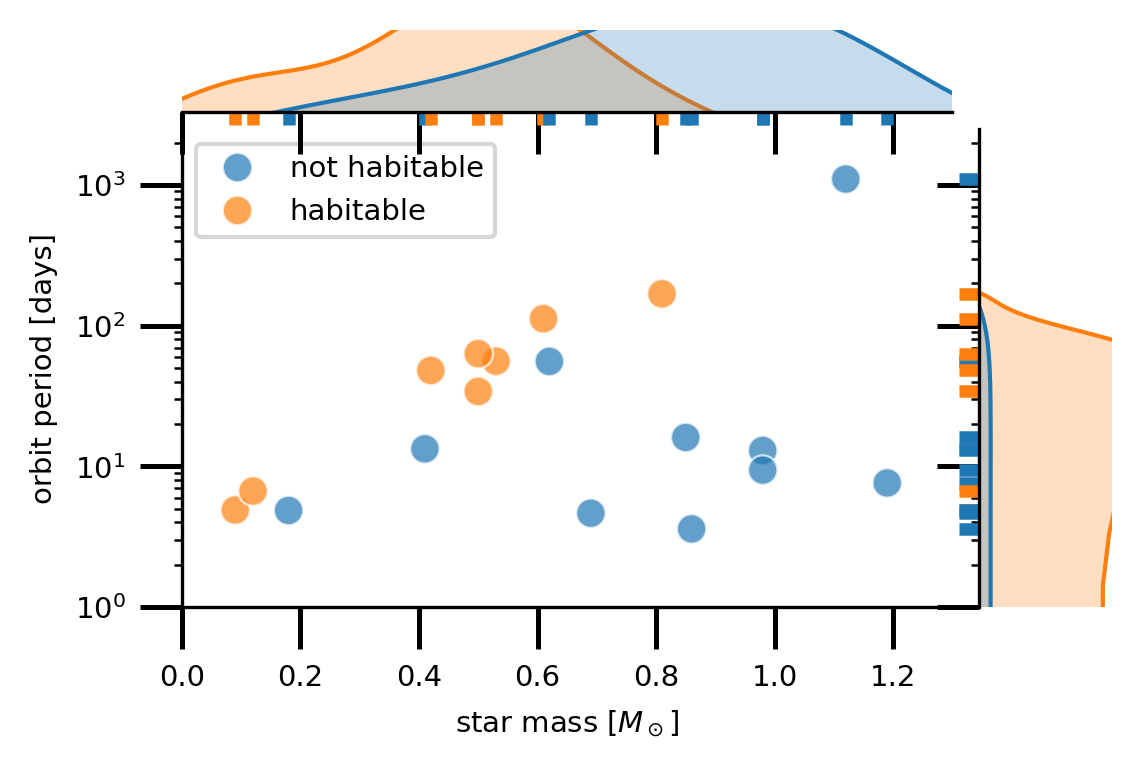

In [100]:
fig1 = plt.figure() # figsize does not work with seaborn
p = sns.jointplot(x='S_MASS',y='P_PERIOD',hue='P_HABITABLE',data=LearningSet2,height=2.5,s=50,alpha=0.7) # height is in inches
p.fig.set_figwidth(4)
# add ticks for data locations below histograms:
p.plot_marginals(sns.rugplot,height=-0.15,clip_on=False,linewidth=3) 
p.ax_joint.tick_params(labelsize=7)
p.ax_joint.set_yscale('log')
p.set_axis_labels('star mass [$M_\odot$]','orbit period [days]',fontsize=7) # needed this to add units
p.ax_joint.legend(fontsize=7,loc='upper left') # manual change of labels doesn't seem to work right
p.ax_joint.set_xlim([0,1.3])
#plt.savefig('HabPlanets_fig1.png') # cuts off axis labels

Text(0.5, 0, 'log orbit distance [AU]')

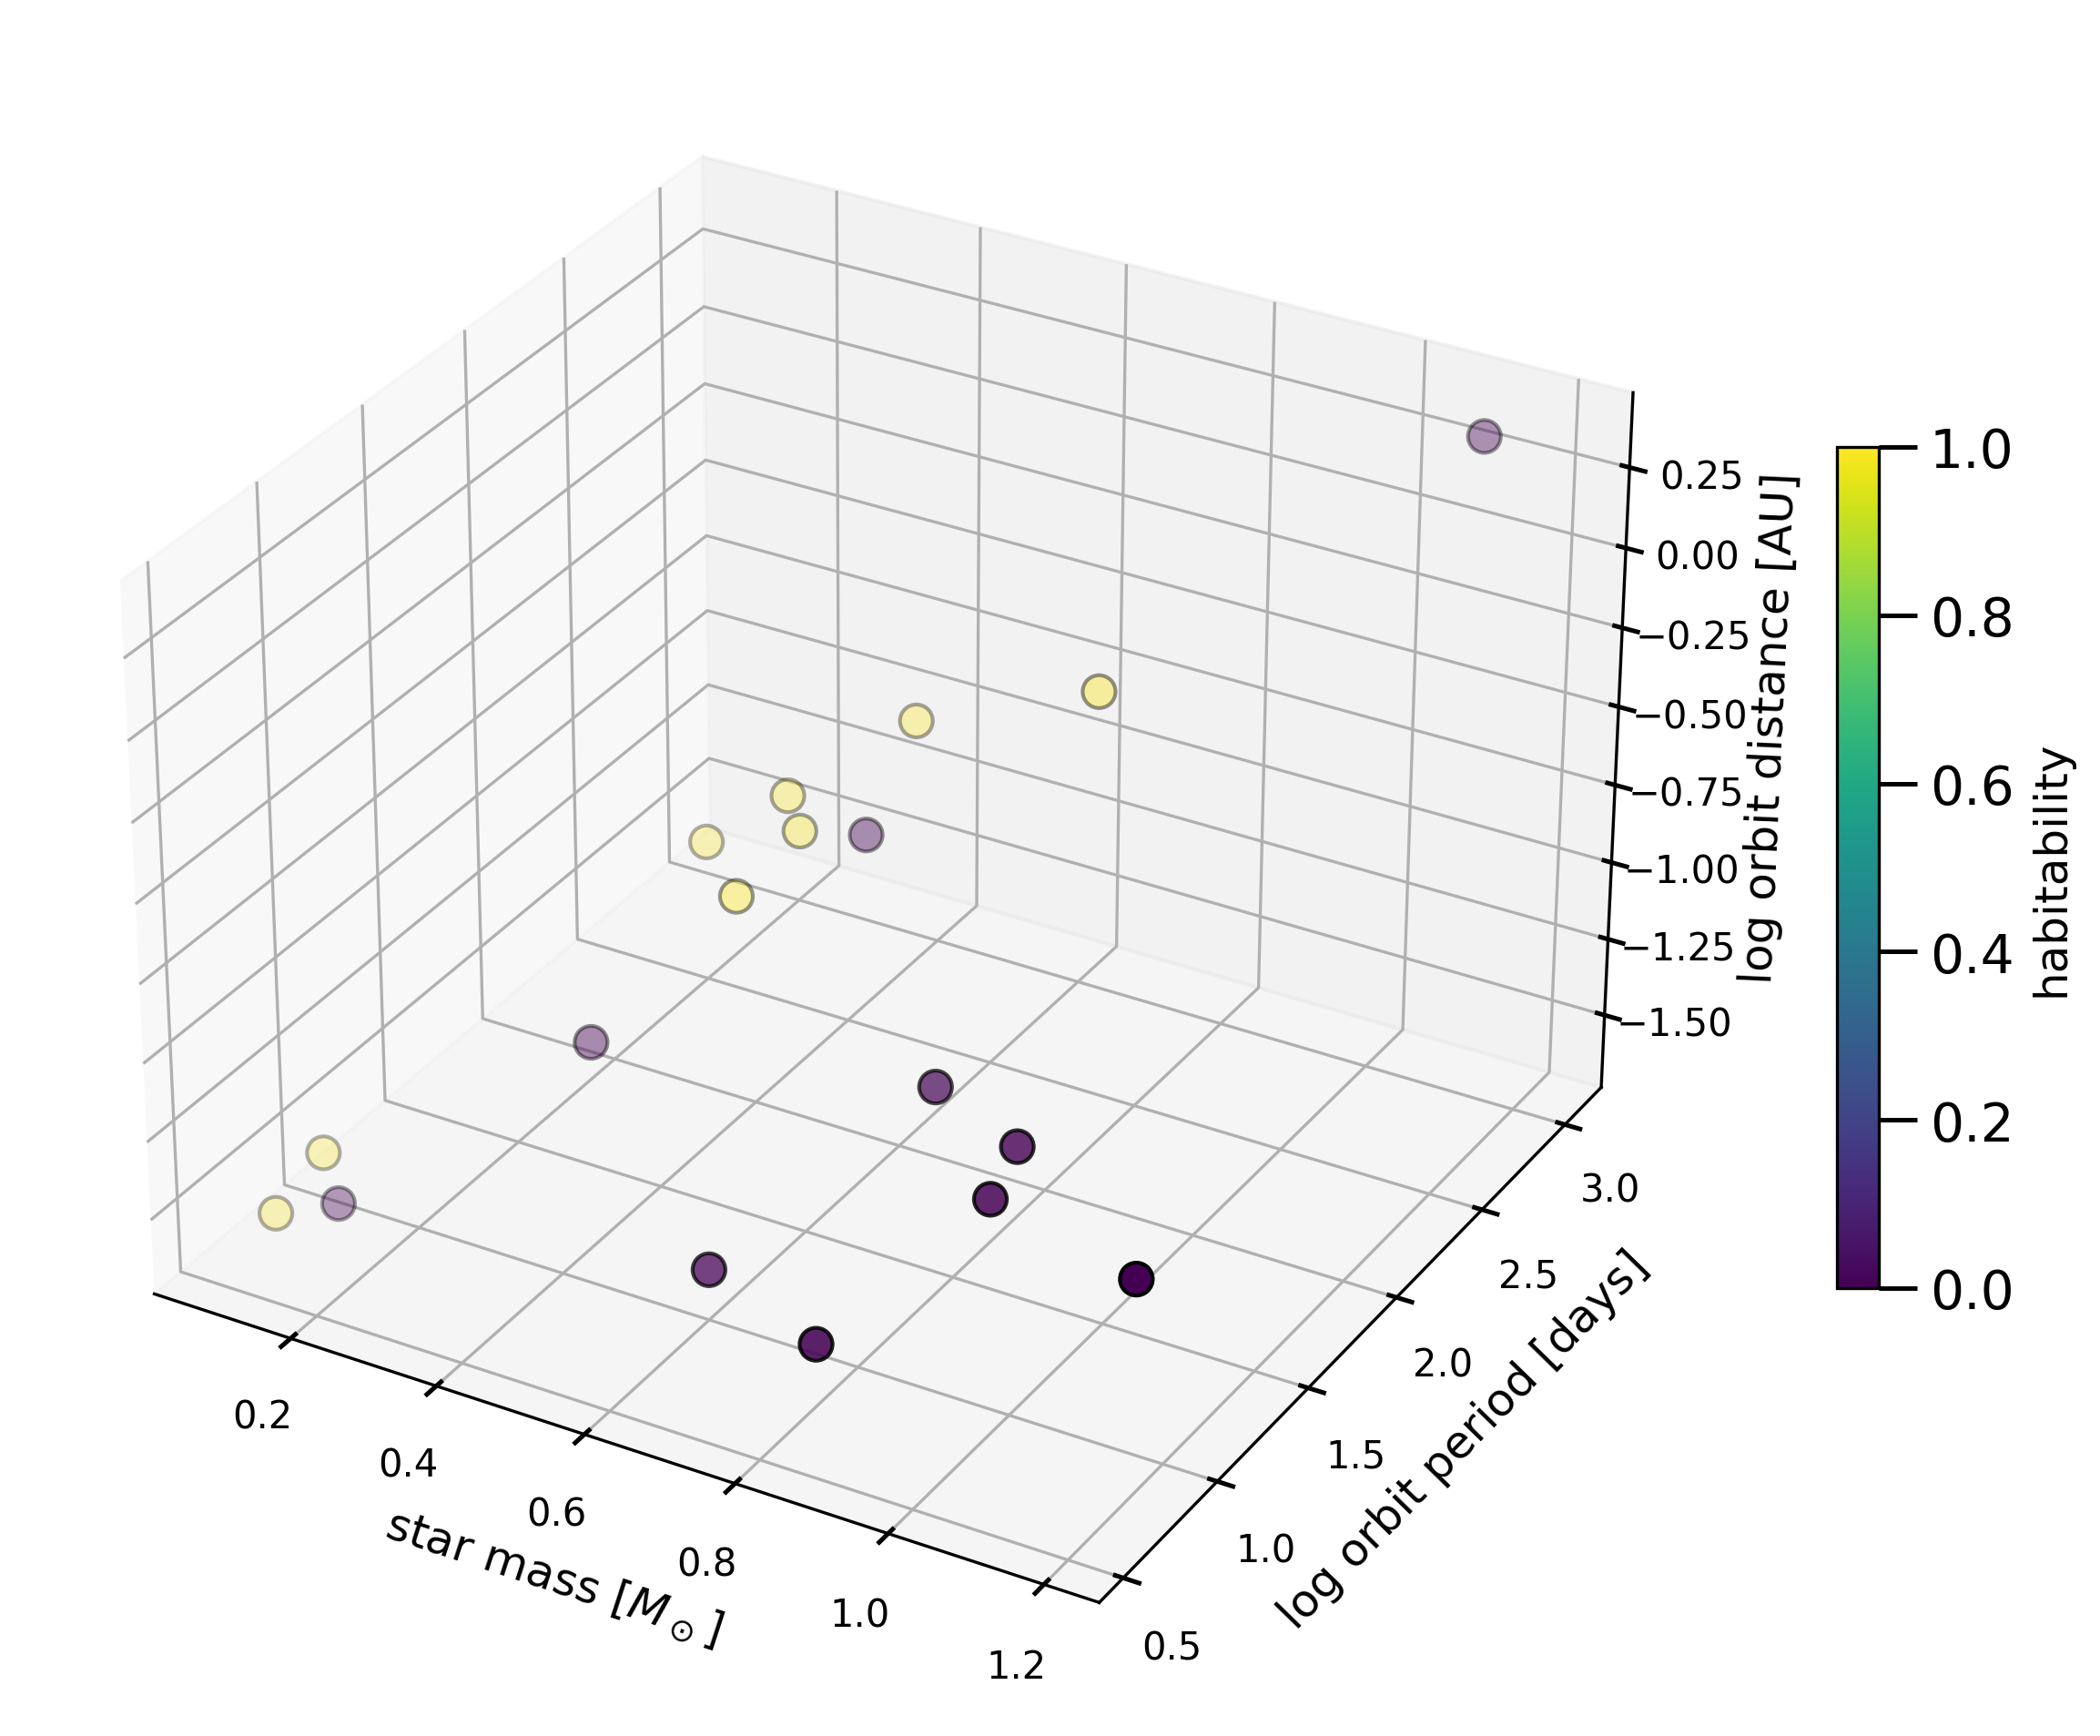

In [101]:
# to make it interactive:\n",
#%matplotlib widget not working
#%pylab qt
fig2 = plt.figure()
ax = fig2.add_subplot(projection='3d')
p = ax.scatter(mass,np.log10(period),np.log10(distance),s=75,c=hab,edgecolors='k')
plt.xlabel('star mass [$M_\odot$]',fontsize=12)
plt.ylabel('log orbit period [days]',fontsize=12)
ax.tick_params(labelsize=10)
p2 = fig2.colorbar(p,shrink=0.5)
p2.set_label(label='habitability',size=12)
ax.set_zlabel('log orbit distance [AU]',fontsize=12)

<Figure size 3600x2400 with 0 Axes>

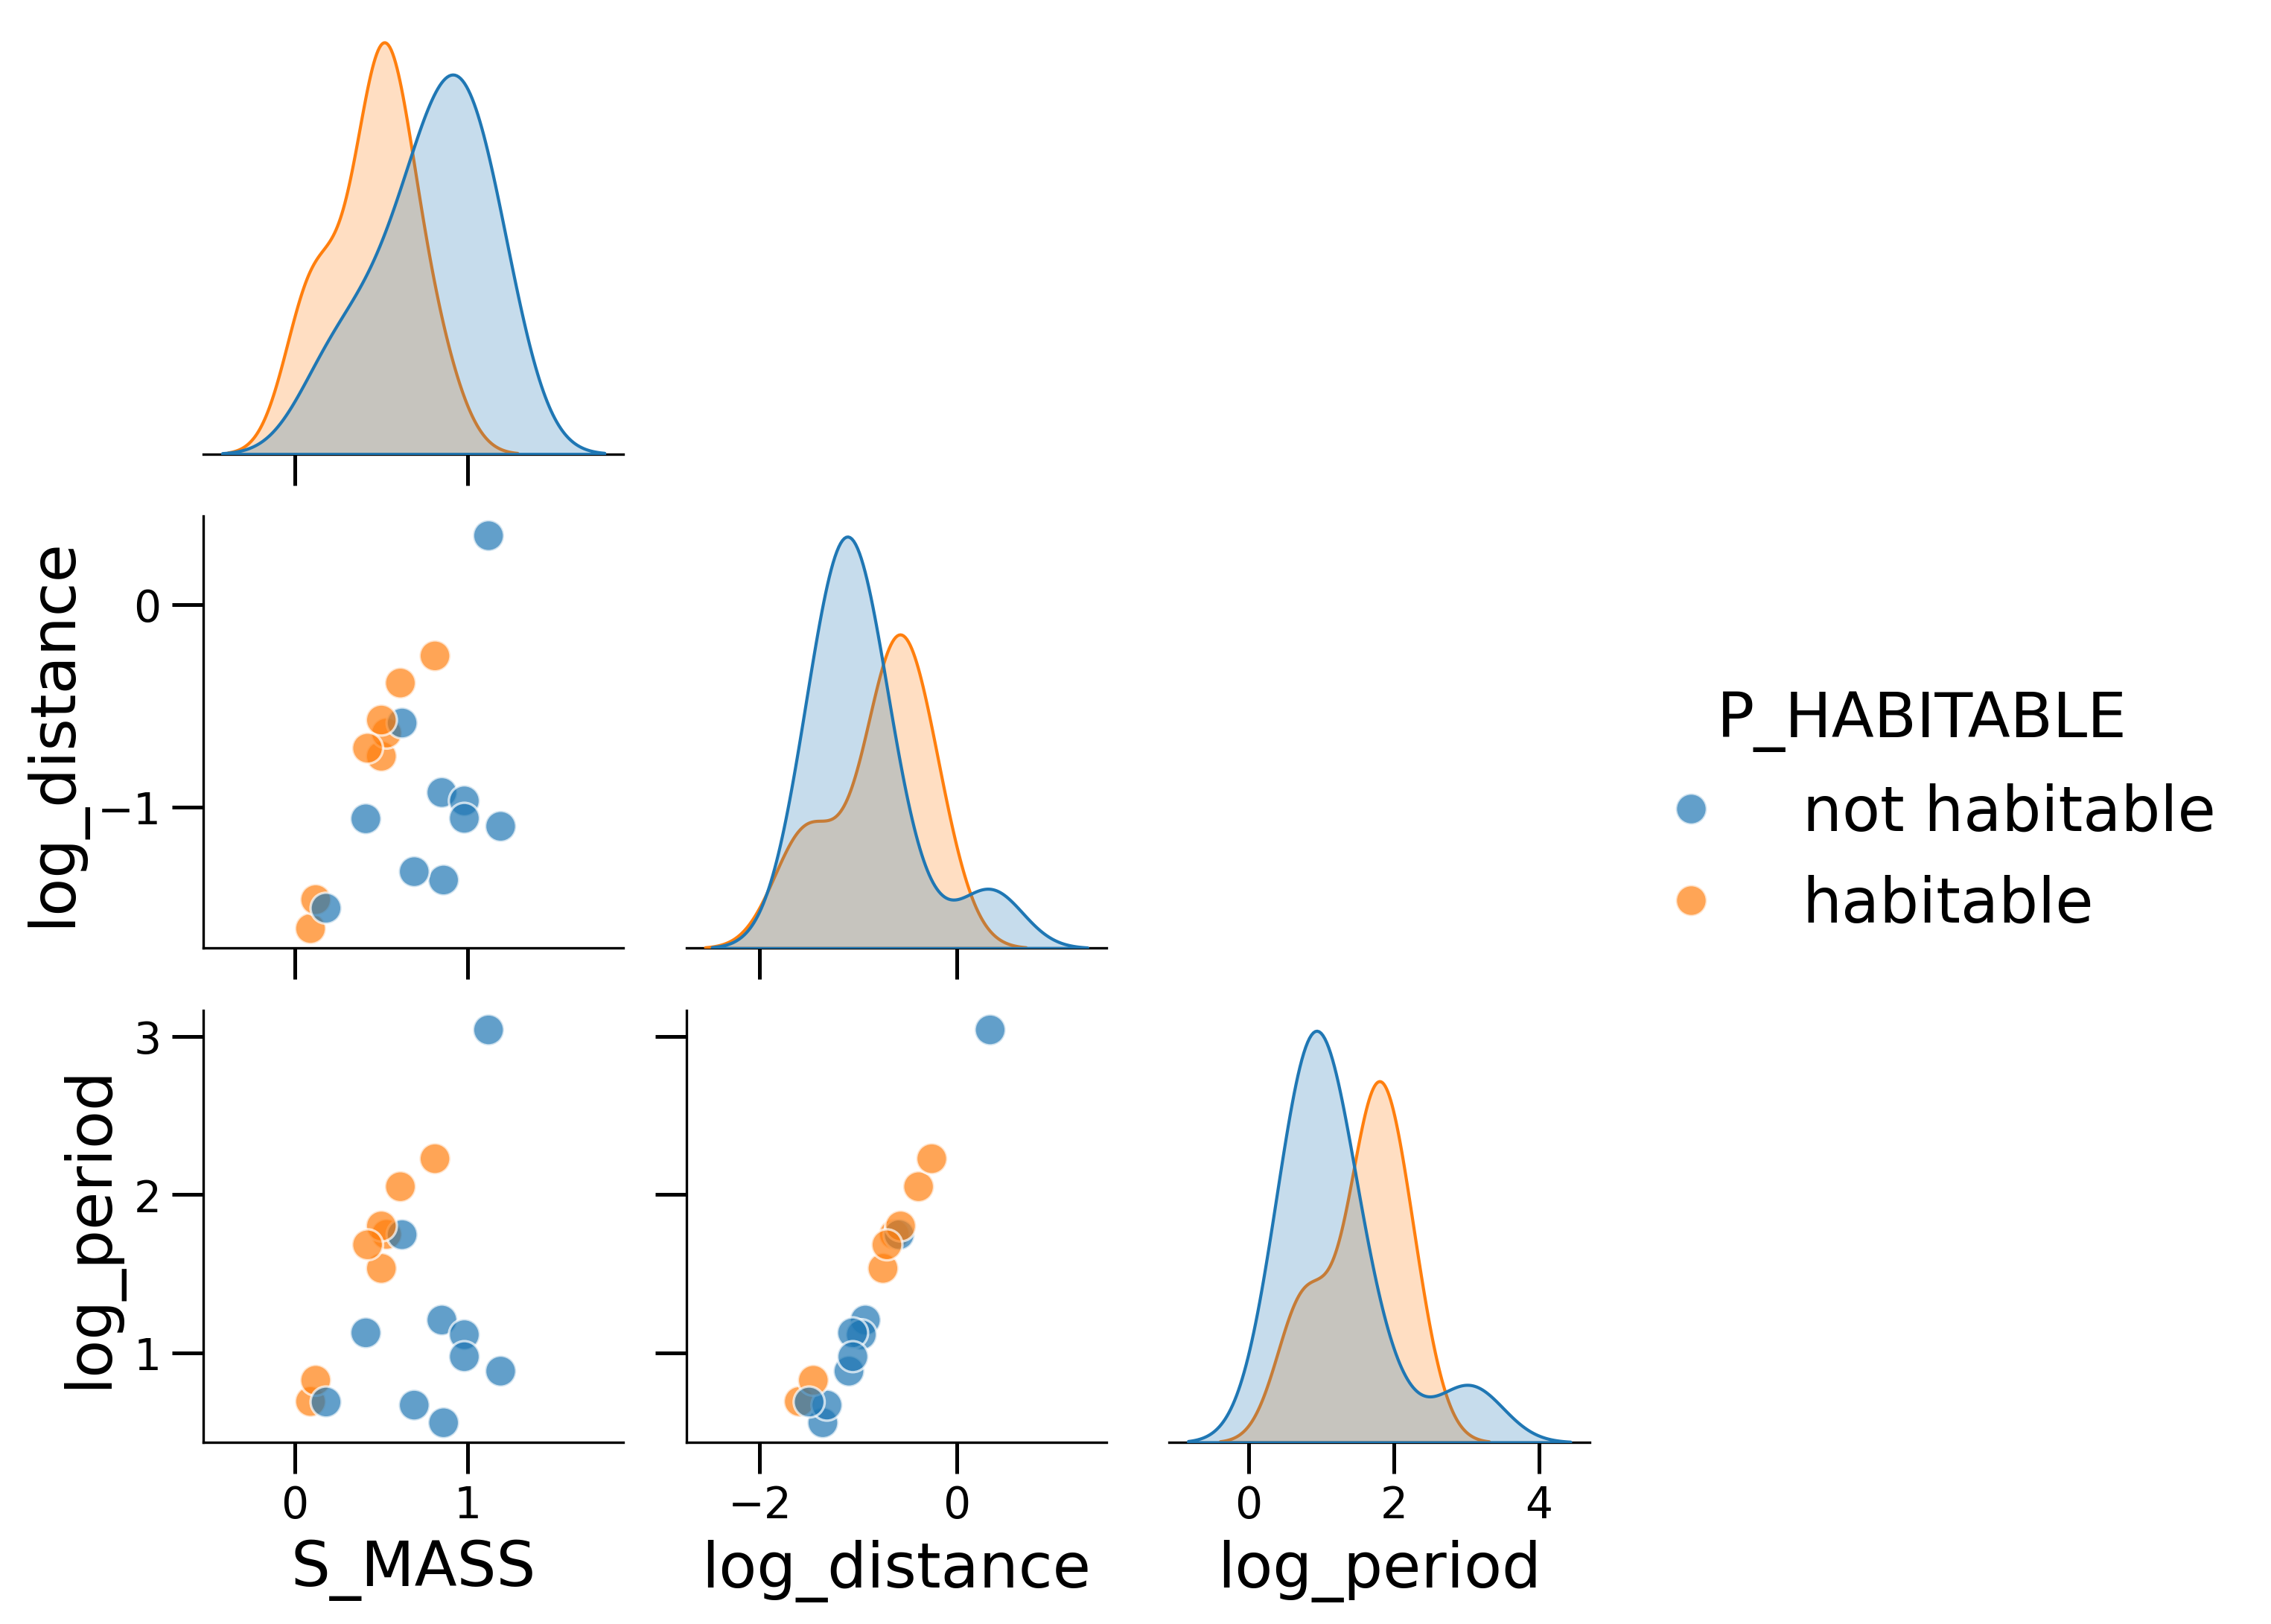

In [102]:
fig3 = plt.figure()
LearningSet2['log_period'] = np.log10(LearningSet2['P_PERIOD'])
LearningSet2['log_distance'] = np.log10(LearningSet2['P_DISTANCE'])
#p=sns.pairplot(LearningSet2,corner=True,hue='P_HABITABLE',plot_kws={"s":100,"alpha":0.7})
p=sns.pairplot(LearningSet2,vars=['S_MASS','log_distance','log_period'],corner=True,hue='P_HABITABLE',plot_kws={"s":100,"alpha":0.7})

C:\Users\seosi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


(1, 2000)

<Figure size 3600x2400 with 0 Axes>

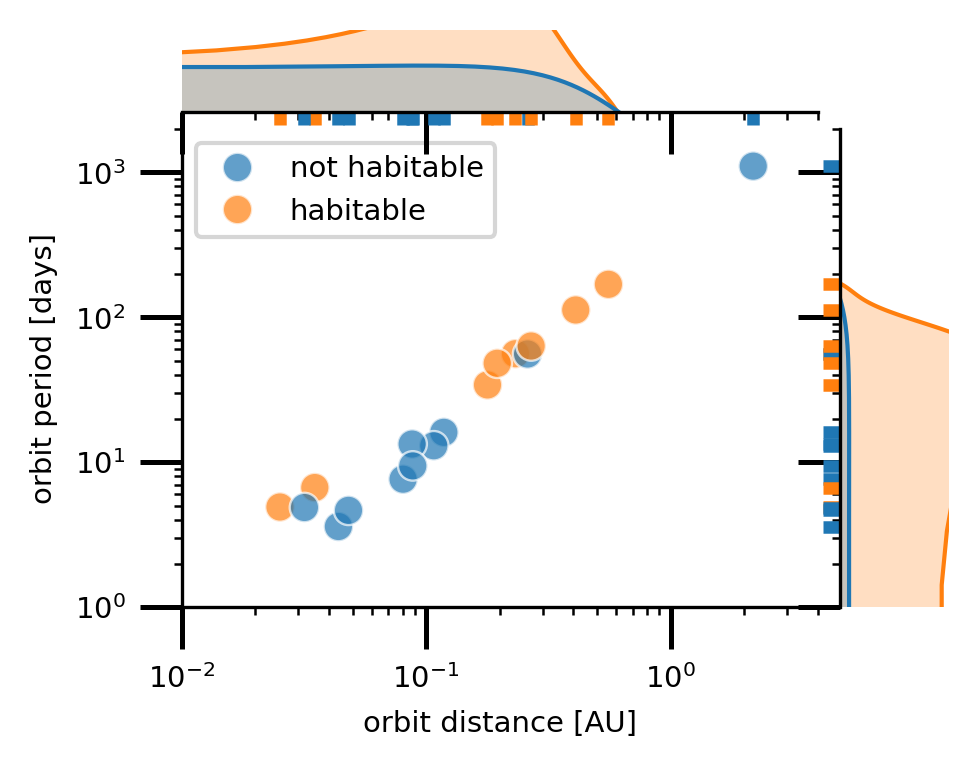

In [103]:
fig4 = plt.figure() # figsize does not work with seaborn
p = sns.jointplot(x='P_DISTANCE',y='P_PERIOD',hue='P_HABITABLE',data=LearningSet2,height=2.5,s=50,alpha=0.7) # height is in inches
p.fig.set_figwidth(3.3)
# add ticks for data locations below histograms:
p.plot_marginals(sns.rugplot,height=-0.15,clip_on=False,linewidth=3) 
p.ax_joint.tick_params(labelsize=7)
p.ax_joint.set_xscale('log')
p.ax_joint.set_yscale('log')
p.set_axis_labels('orbit distance [AU]','orbit period [days]',fontsize=7) # needed this to add units
p.ax_joint.legend(fontsize=7,loc='upper left') # manual change of labels doesn't seem to work right
p.ax_joint.set_xlim([0.01,4])
p.ax_joint.set_ylim([1,2000])

C:\Users\seosi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


(1, 2000)

<Figure size 3600x2400 with 0 Axes>

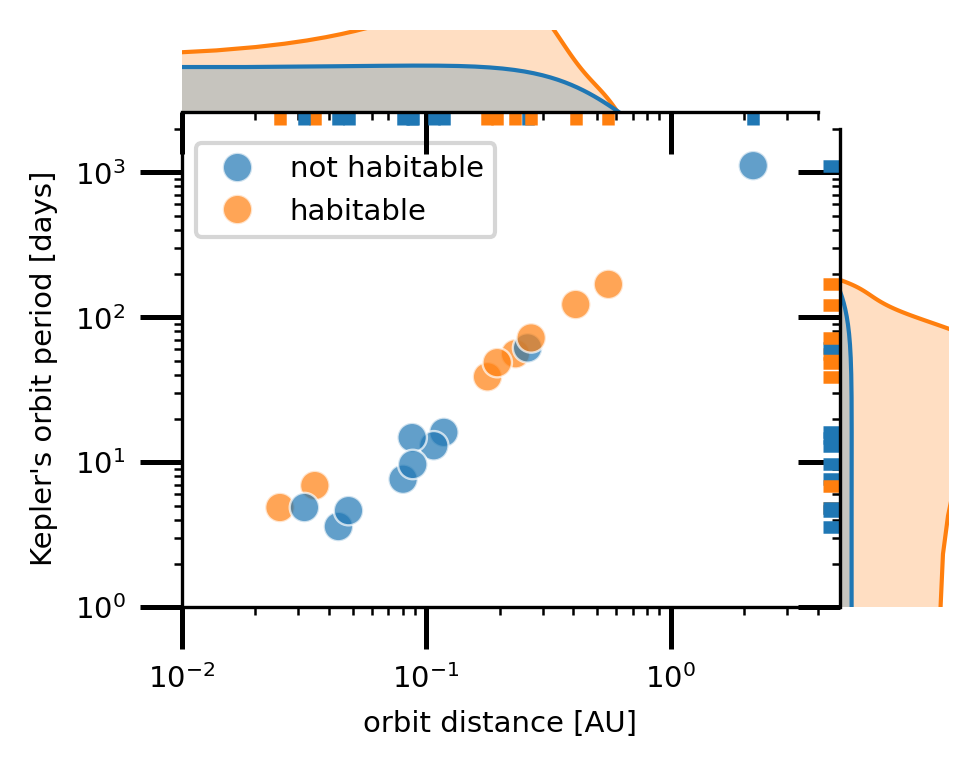

In [104]:
fig5 = plt.figure() # figsize does not work with seaborn
p = sns.jointplot(x='P_DISTANCE',y='p_from_dist',hue='P_HABITABLE',data=LearningSet2,height=2.5,s=50,alpha=0.7) # height is in inches
p.fig.set_figwidth(3.3)
# add ticks for data locations below histograms:
p.plot_marginals(sns.rugplot,height=-0.15,clip_on=False,linewidth=3) 
p.ax_joint.tick_params(labelsize=7)
p.ax_joint.set_xscale('log')
p.ax_joint.set_yscale('log')
p.set_axis_labels('orbit distance [AU]',"Kepler\'s orbit period [days]",fontsize=7) # needed this to add units
p.ax_joint.legend(fontsize=7,loc='upper left') # manual change of labels doesn't seem to work right
p.ax_joint.set_xlim([0.01,4])
p.ax_joint.set_ylim([1,2000])

### Let's pick the same train/test set we had in the exercise.

Note the use of ".iloc" (integer location) to access indices in data frames.

We can now creat a train and a test set. Normally this would happen at random, using the function train_test_split, but here we are following along with the book.

In [105]:
TrainSet =  LearningSet1.iloc[:13,:]  

TestSet = LearningSet1.iloc[13:,:]

In [106]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [107]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


We also need to split the train and test sets in features and labels.

In [108]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features for the train set
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features for the test set

ytrain = TrainSet.P_HABITABLE #target for the train set
ytest = TestSet.P_HABITABLE  #target for the test set

### We are now ready to fit the data with our decision tree!

Note: The features are always randomly permuted at each split. Therefore, the best found split may vary, even with the same training data, if the improvement of the criterion is identical for several splits enumerated during the search of the best split. 

To obtain a deterministic behaviour during fitting, random_state has to be fixed.


In [109]:
model = DecisionTreeClassifier(random_state = 3) #This is how we specify which method we'd like to use, and any parameters.

model.fit(Xtrain, ytrain) #This tiny line is how we build models in sklearn.

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### Finally, we can visualize the tree.

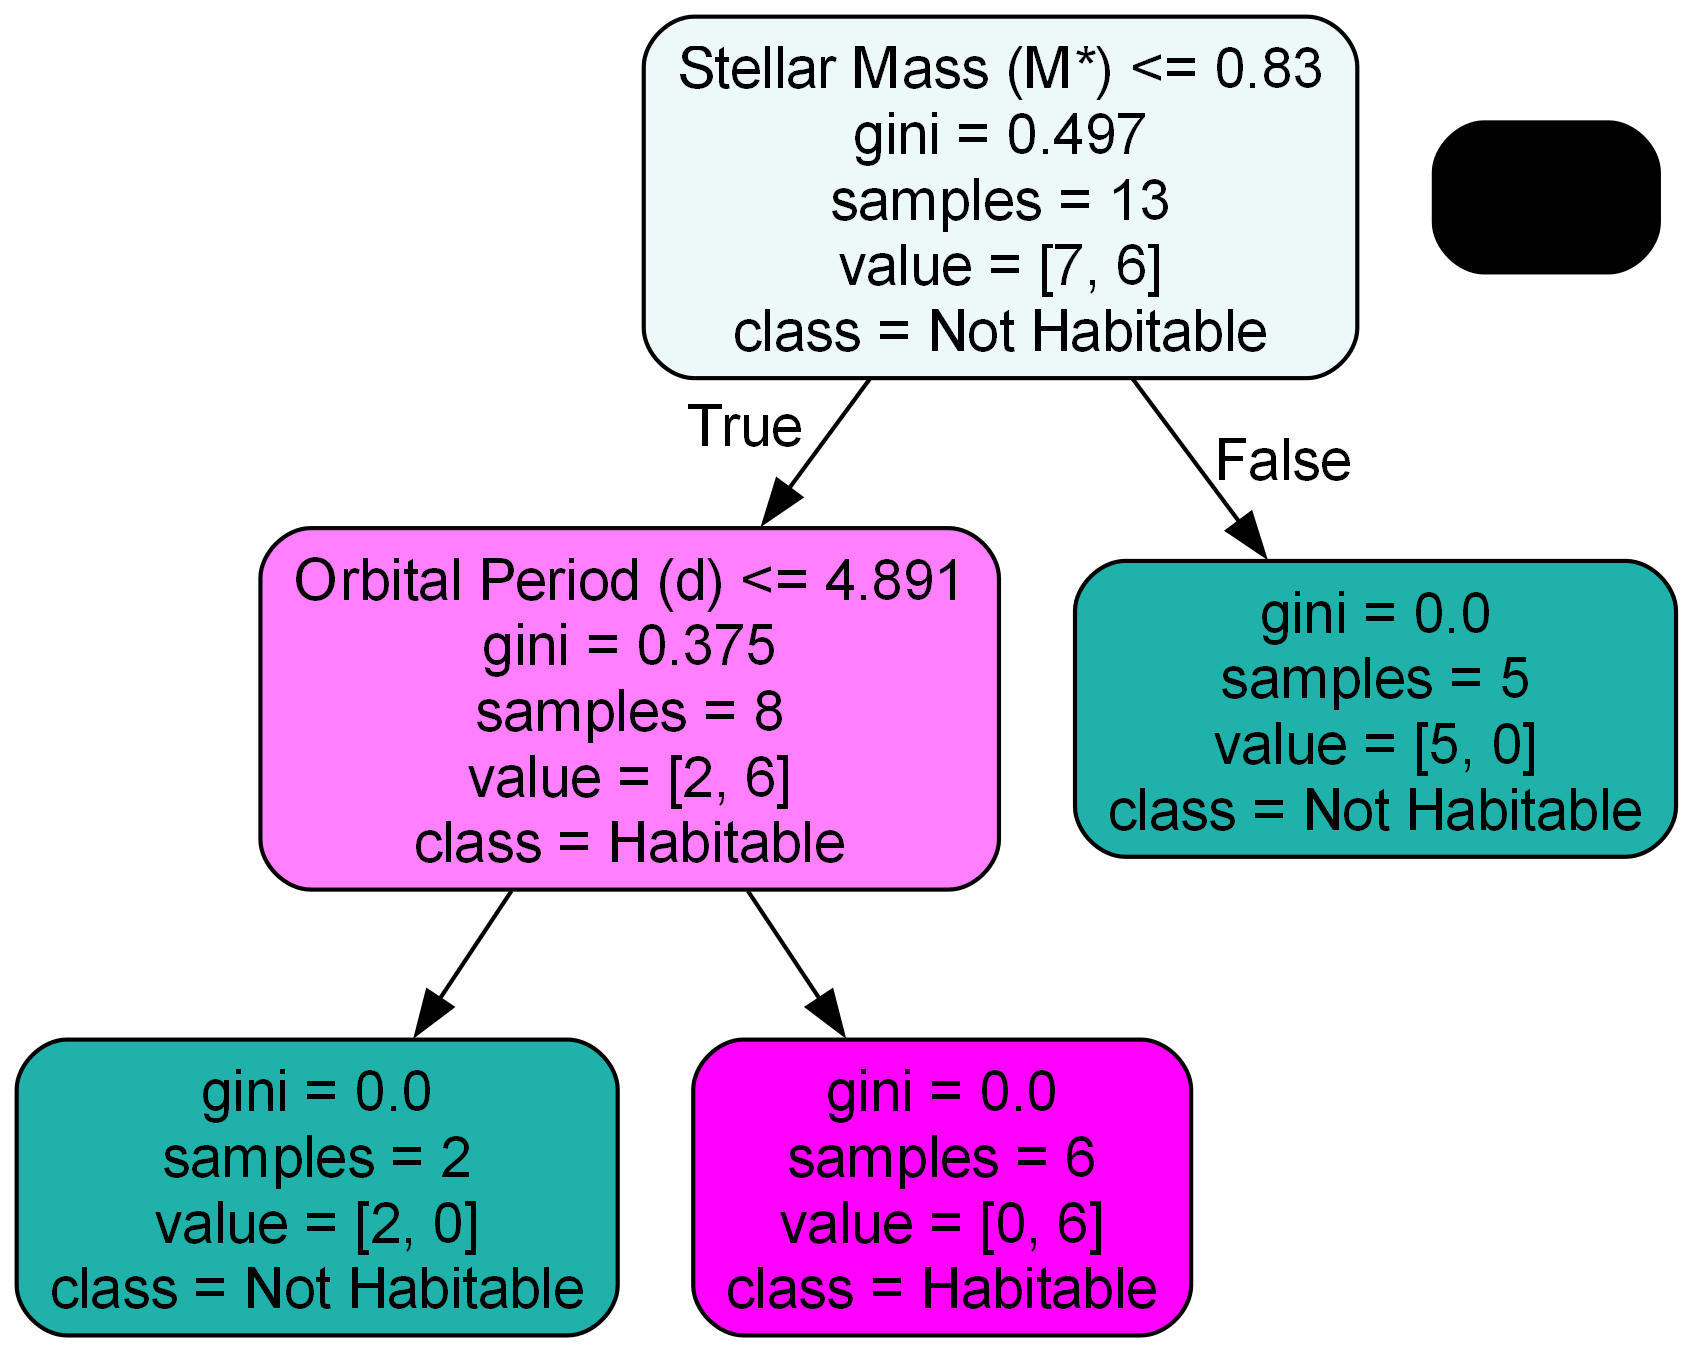

In [110]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
            rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### This is an alternative visualization, which only relies on the sklearn package.

[Text(0.6, 0.8333333333333334, 'Stellar Mass (M*) <= 0.83\ngini = 0.497\nsamples = 13\nvalue = [7, 6]\nclass = Not Habitable'),
 Text(0.4, 0.5, 'Orbital Period (d) <= 4.891\ngini = 0.375\nsamples = 8\nvalue = [2, 6]\nclass = Habitable'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = Not Habitable'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]\nclass = Habitable'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = Not Habitable'),
 Text(0.7, 0.6666666666666667, '  False')]

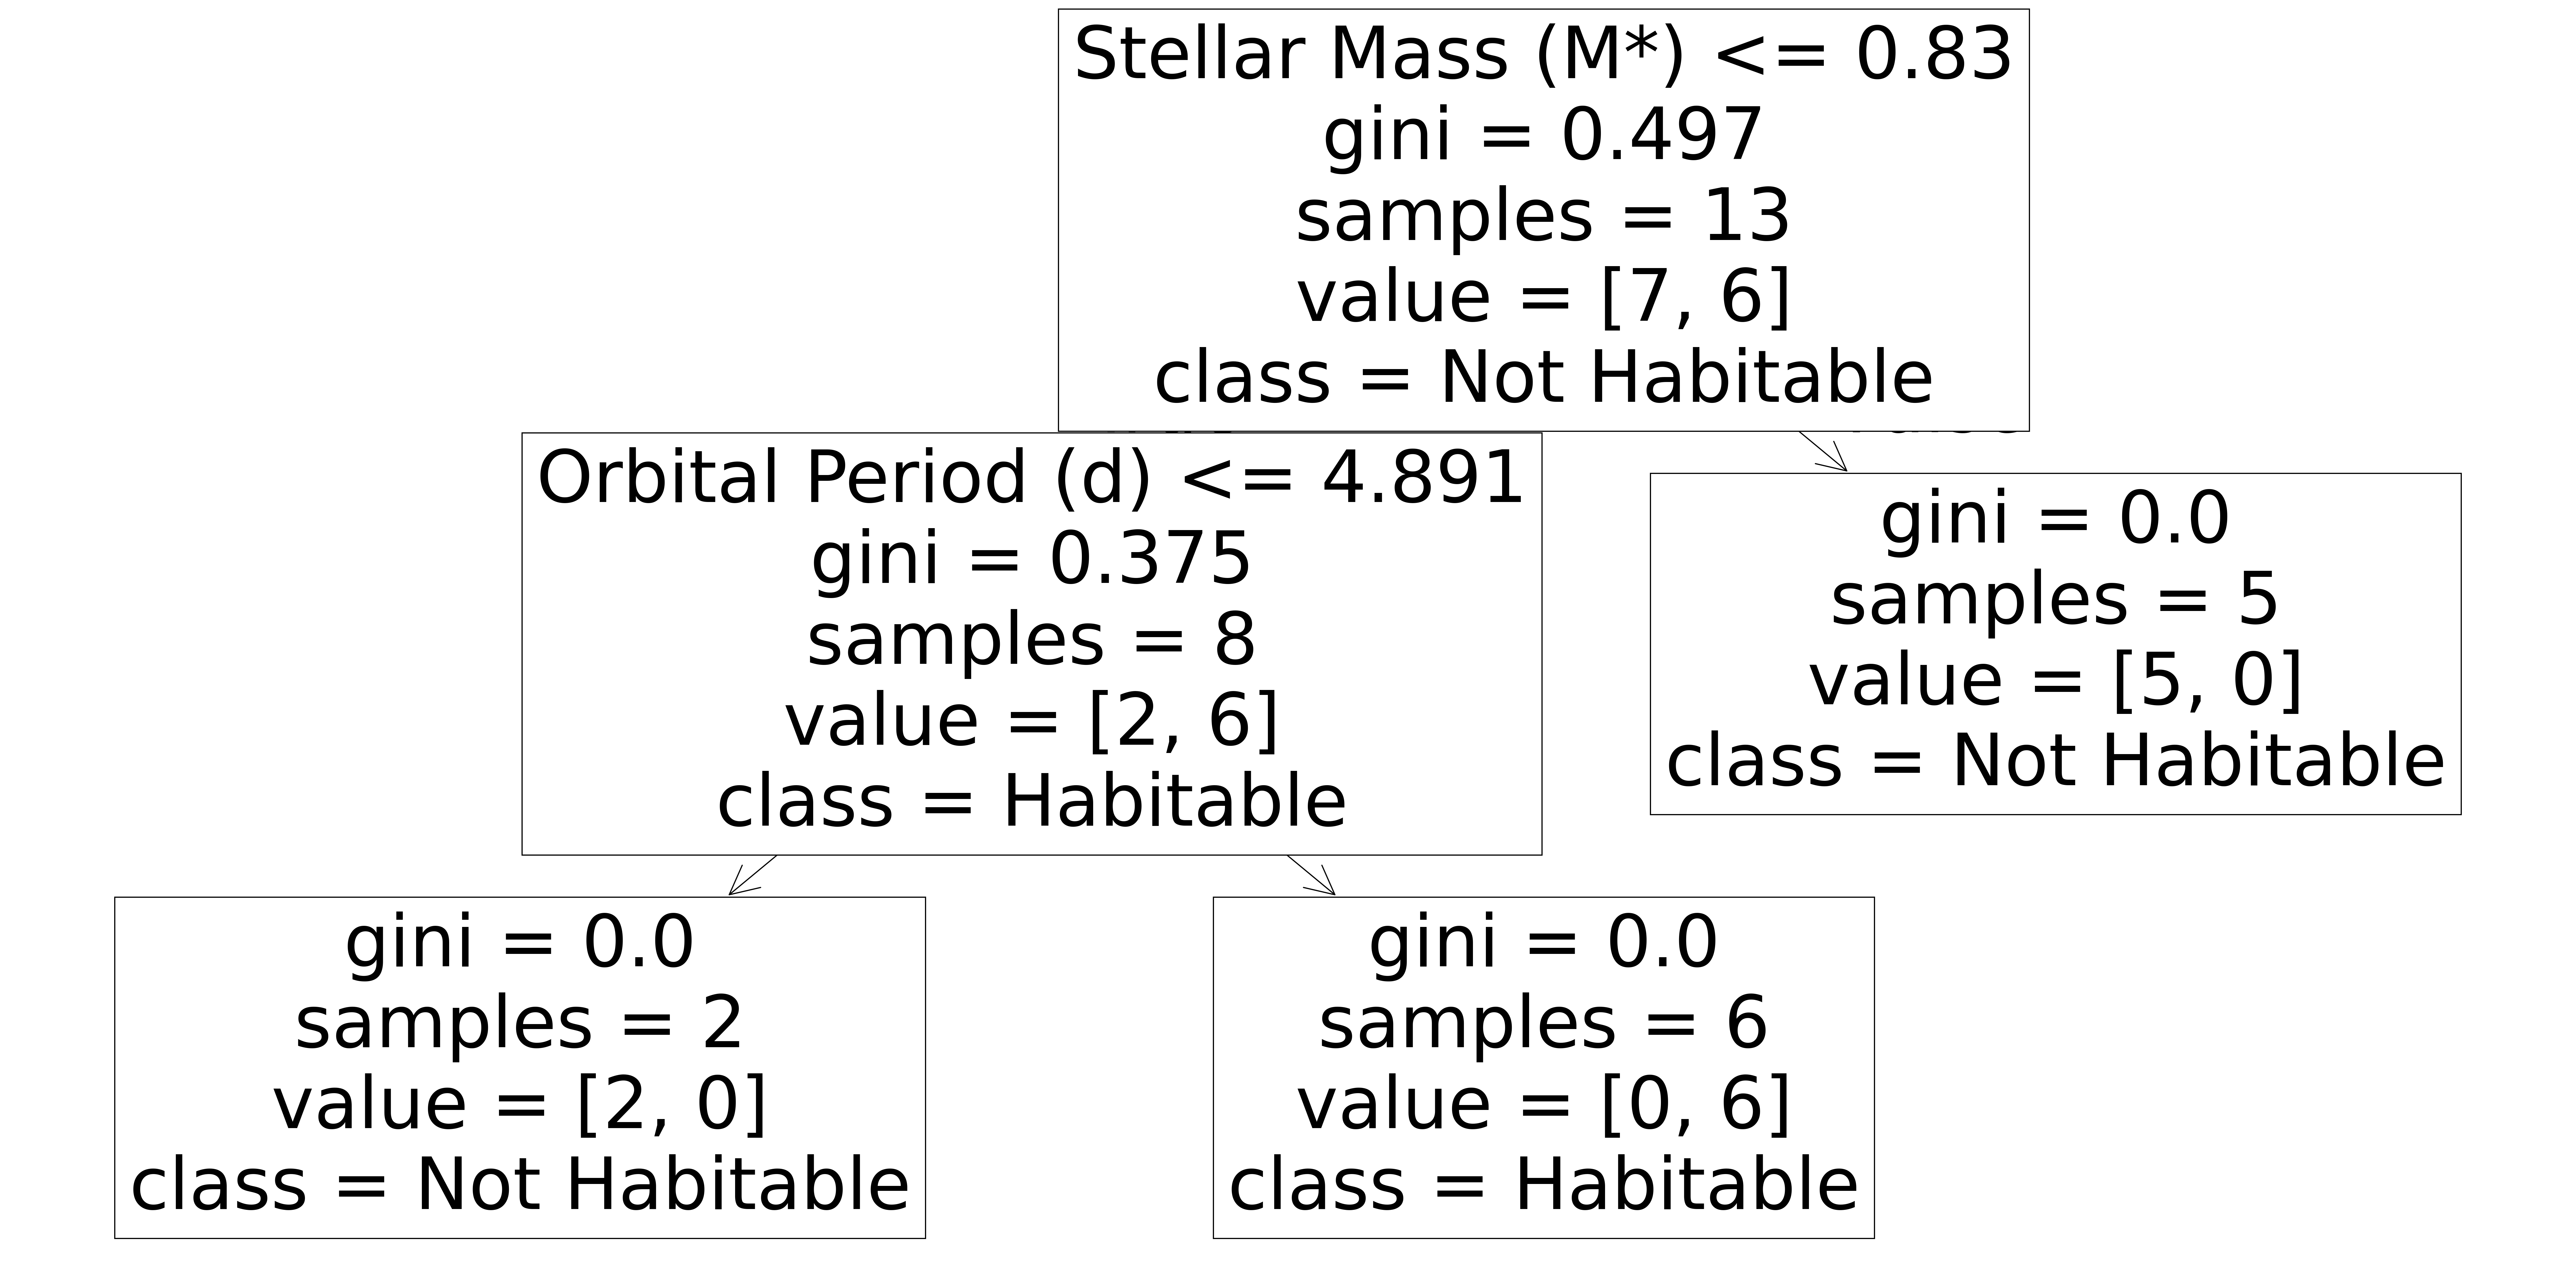

In [111]:
fig6 = plt.figure(figsize=(40,20))  # customize according to the size of your tree
tree.plot_tree(model, feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'], class_names = ['Not Habitable','Habitable'])
#plt.show()

### We can also visualize the decisions of the classifier. The shading indicates the predicted label, while the color of the markers indicates the true labe):

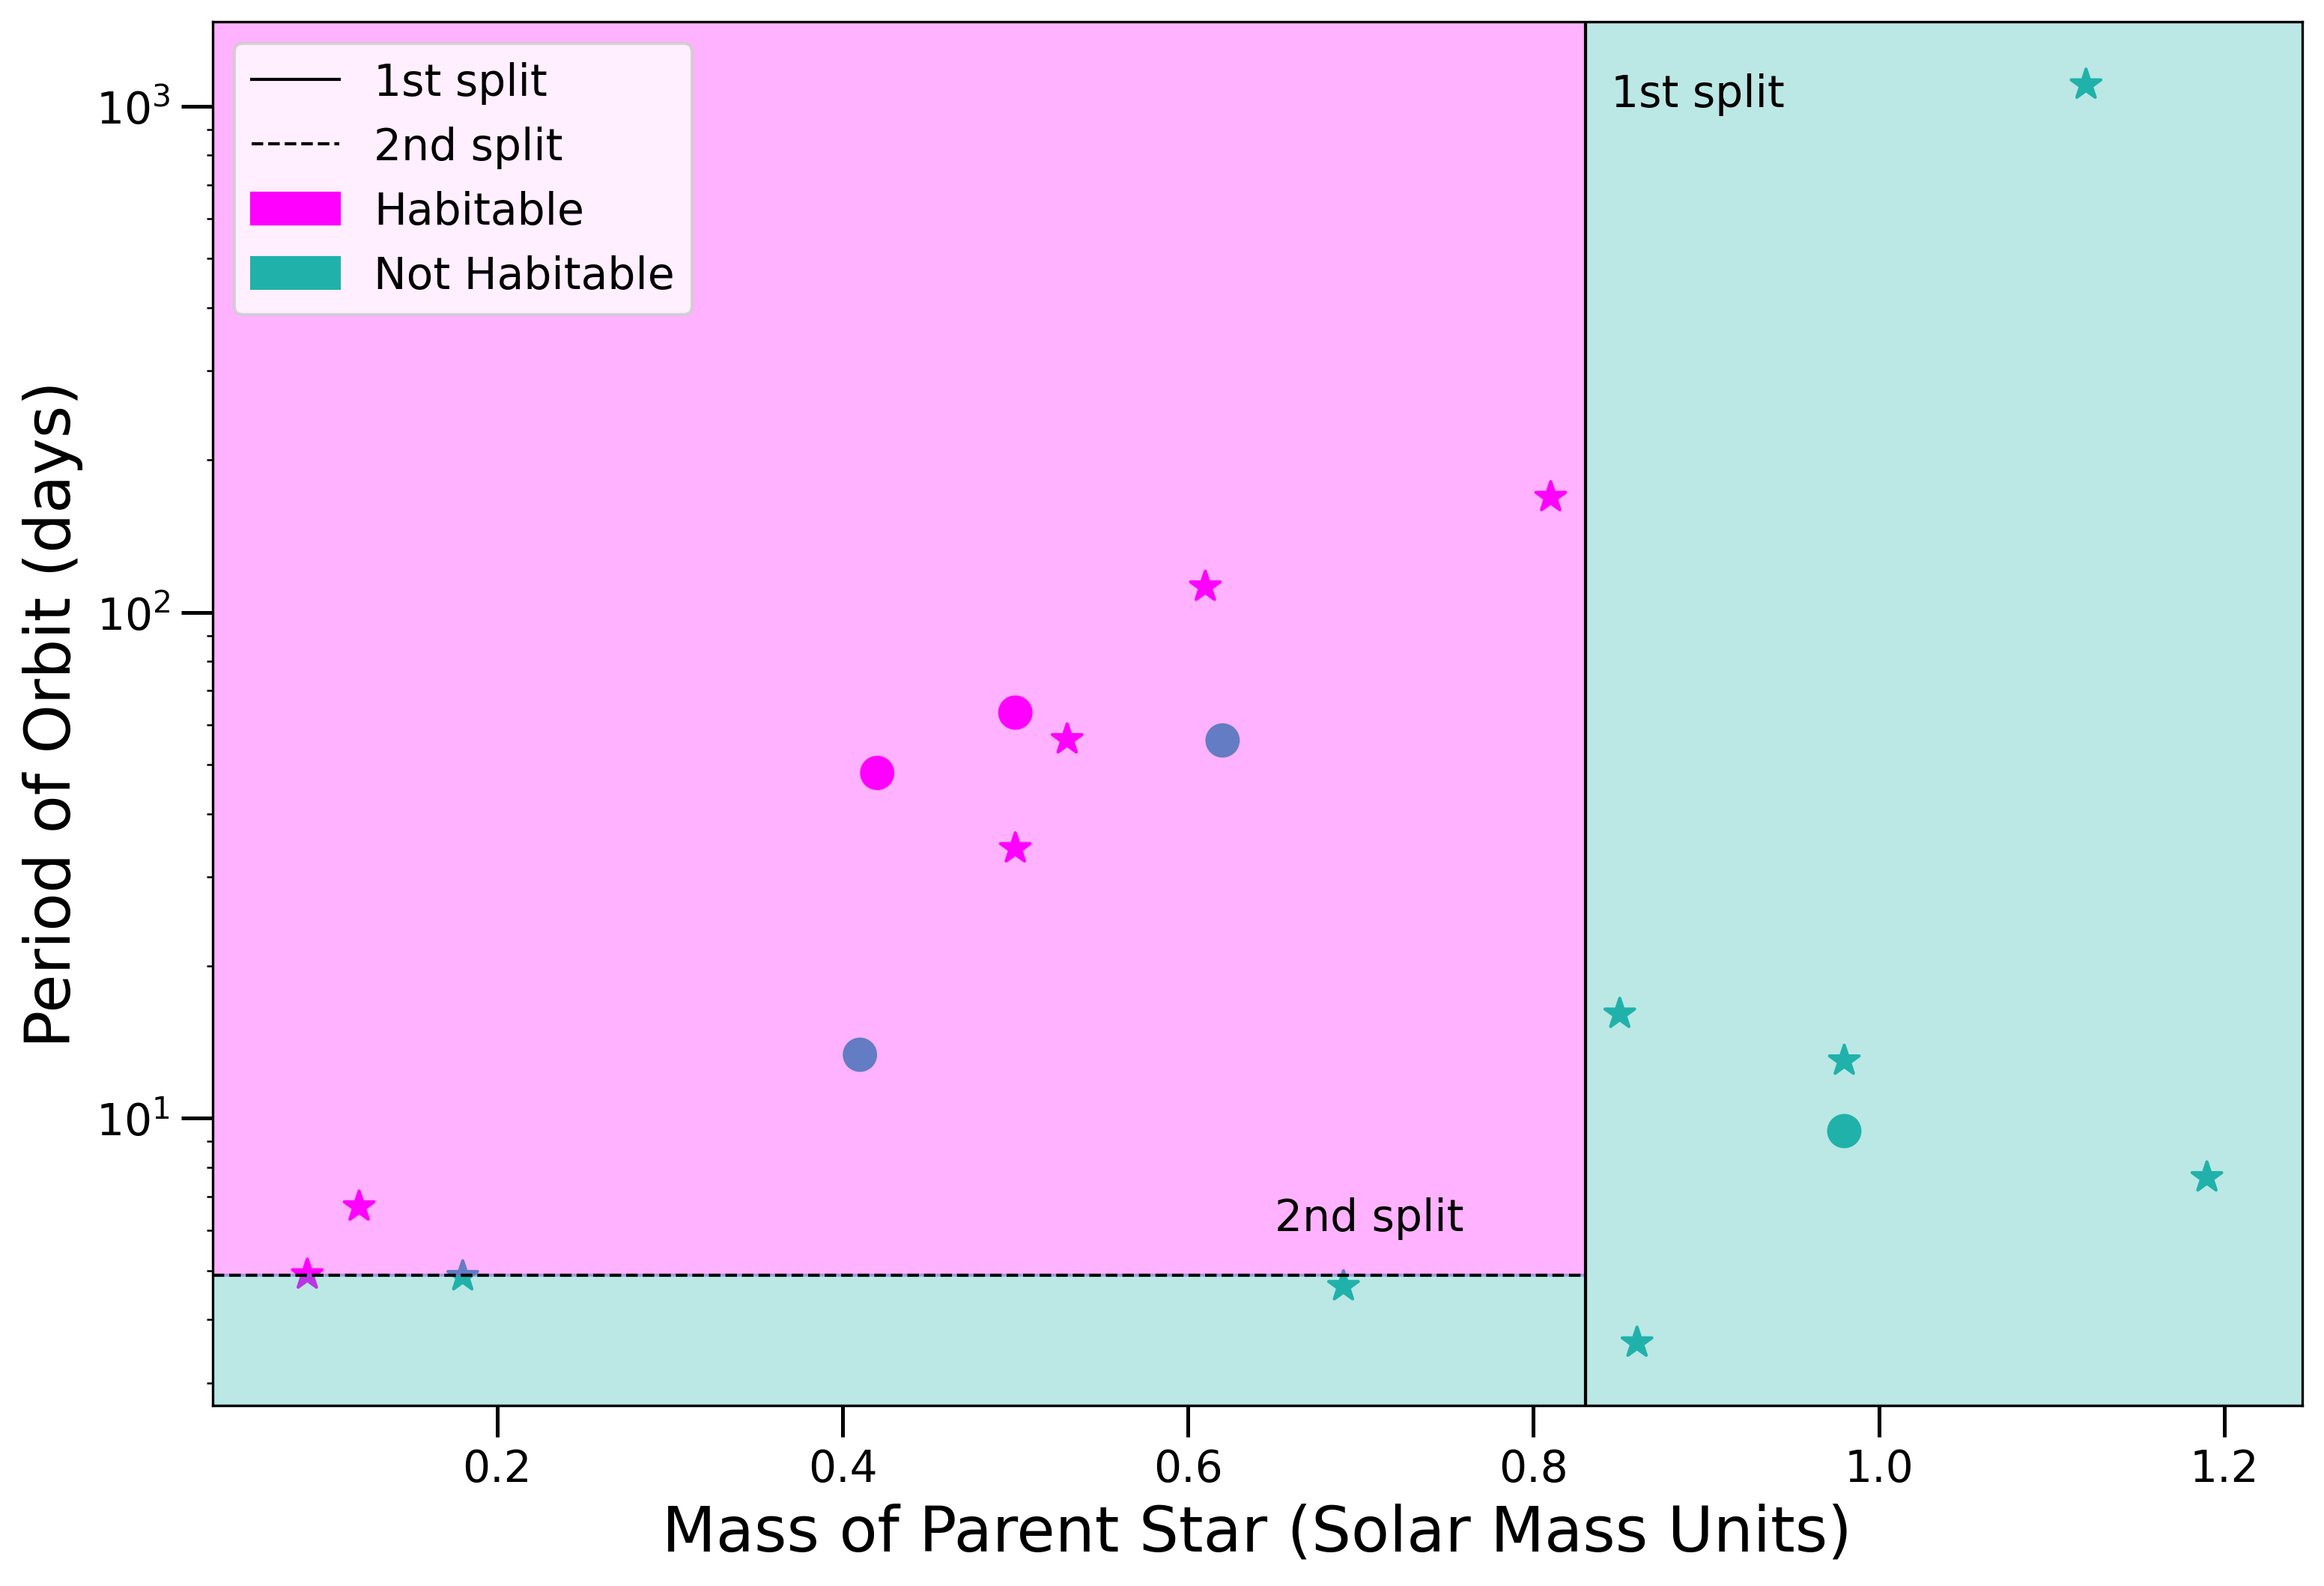

In [112]:
fig7 = plt.figure(figsize=(12,8))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#Will now plot the train set and test set points
plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')
plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')
plt.yscale('log')
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');

#I can add the splits to the plot
plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')
plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')
plt.text(0.845, 10**3, '1st split', fontsize=14)
plt.text(0.65, 6, '2nd split', fontsize=14)

#Add legend, including unlabeled objects

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')
plt.legend();
ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[2].set_color('k')
leg.legend_handles[3].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[2].set_color('k') # had to update to new matplotlib vocab
leg.legend_handles[3].set_color('k')

plt.legend(handles=[leg.legend_handles[2],leg.legend_handles[3], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);

### Questions: 
    
- What is the accuracy (percentage of correct classifications) on the training set? 100%


- How about on the test set (you have to run the test example through the tree, or look at the figure above)? 3/5 or 60%

### We want, of course, to be able to answer the questions in code as well.


In [113]:
ypred = model.predict(Xtest) #how to generate predicted labels on test set

In [114]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

In [115]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

make a confusion matrix

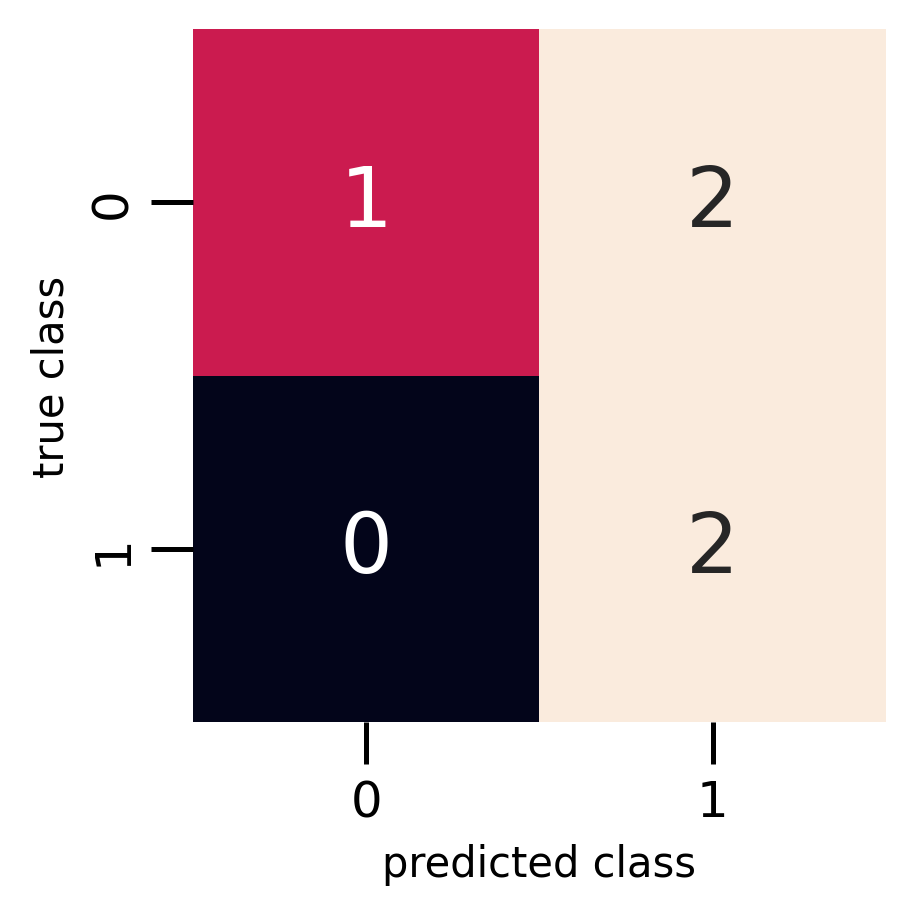

In [116]:
#mat = metrics.confusion_matrix(ytrain, model.predict(Xtrain))
mat = metrics.confusion_matrix(ytest, ypred)
fig8 = plt.figure(figsize=(3,3))
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted class',fontsize=10)
plt.ylabel('true class',fontsize=10)
plt.tick_params(labelsize=12)

Try a model with only two features since period is almost degenerate with period (highly correlated).

In [117]:
Xtrain2D = TrainSet.drop(['P_NAME','P_PERIOD','P_HABITABLE'],axis=1) #features for the train set
Xtest2D = TestSet.drop(['P_NAME','P_PERIOD','P_HABITABLE'],axis=1) #features for the test set
model.fit(Xtrain2D, ytrain) #This tiny line is how we build models in sklearn.
print(metrics.accuracy_score(ytrain, model.predict(Xtrain2D))) #train score

ypred2D = model.predict(Xtest2D) #how to generate predicted labels on test set
print(metrics.accuracy_score(ytest, ypred2D)) #test score: 0.8 (0.6 if we drop distance instead of period)

1.0
0.8


2D grid of classification probabilities:

In [118]:
mm, dd = np.meshgrid(np.linspace(0,1.25), np.logspace(-1.7,0.5))
prob = model.predict_proba(np.c_[mm.ravel(), dd.ravel()]) # c_ is similar to column_stack here
prob = prob[:,1].reshape(mm.shape)

C:\Users\seosi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


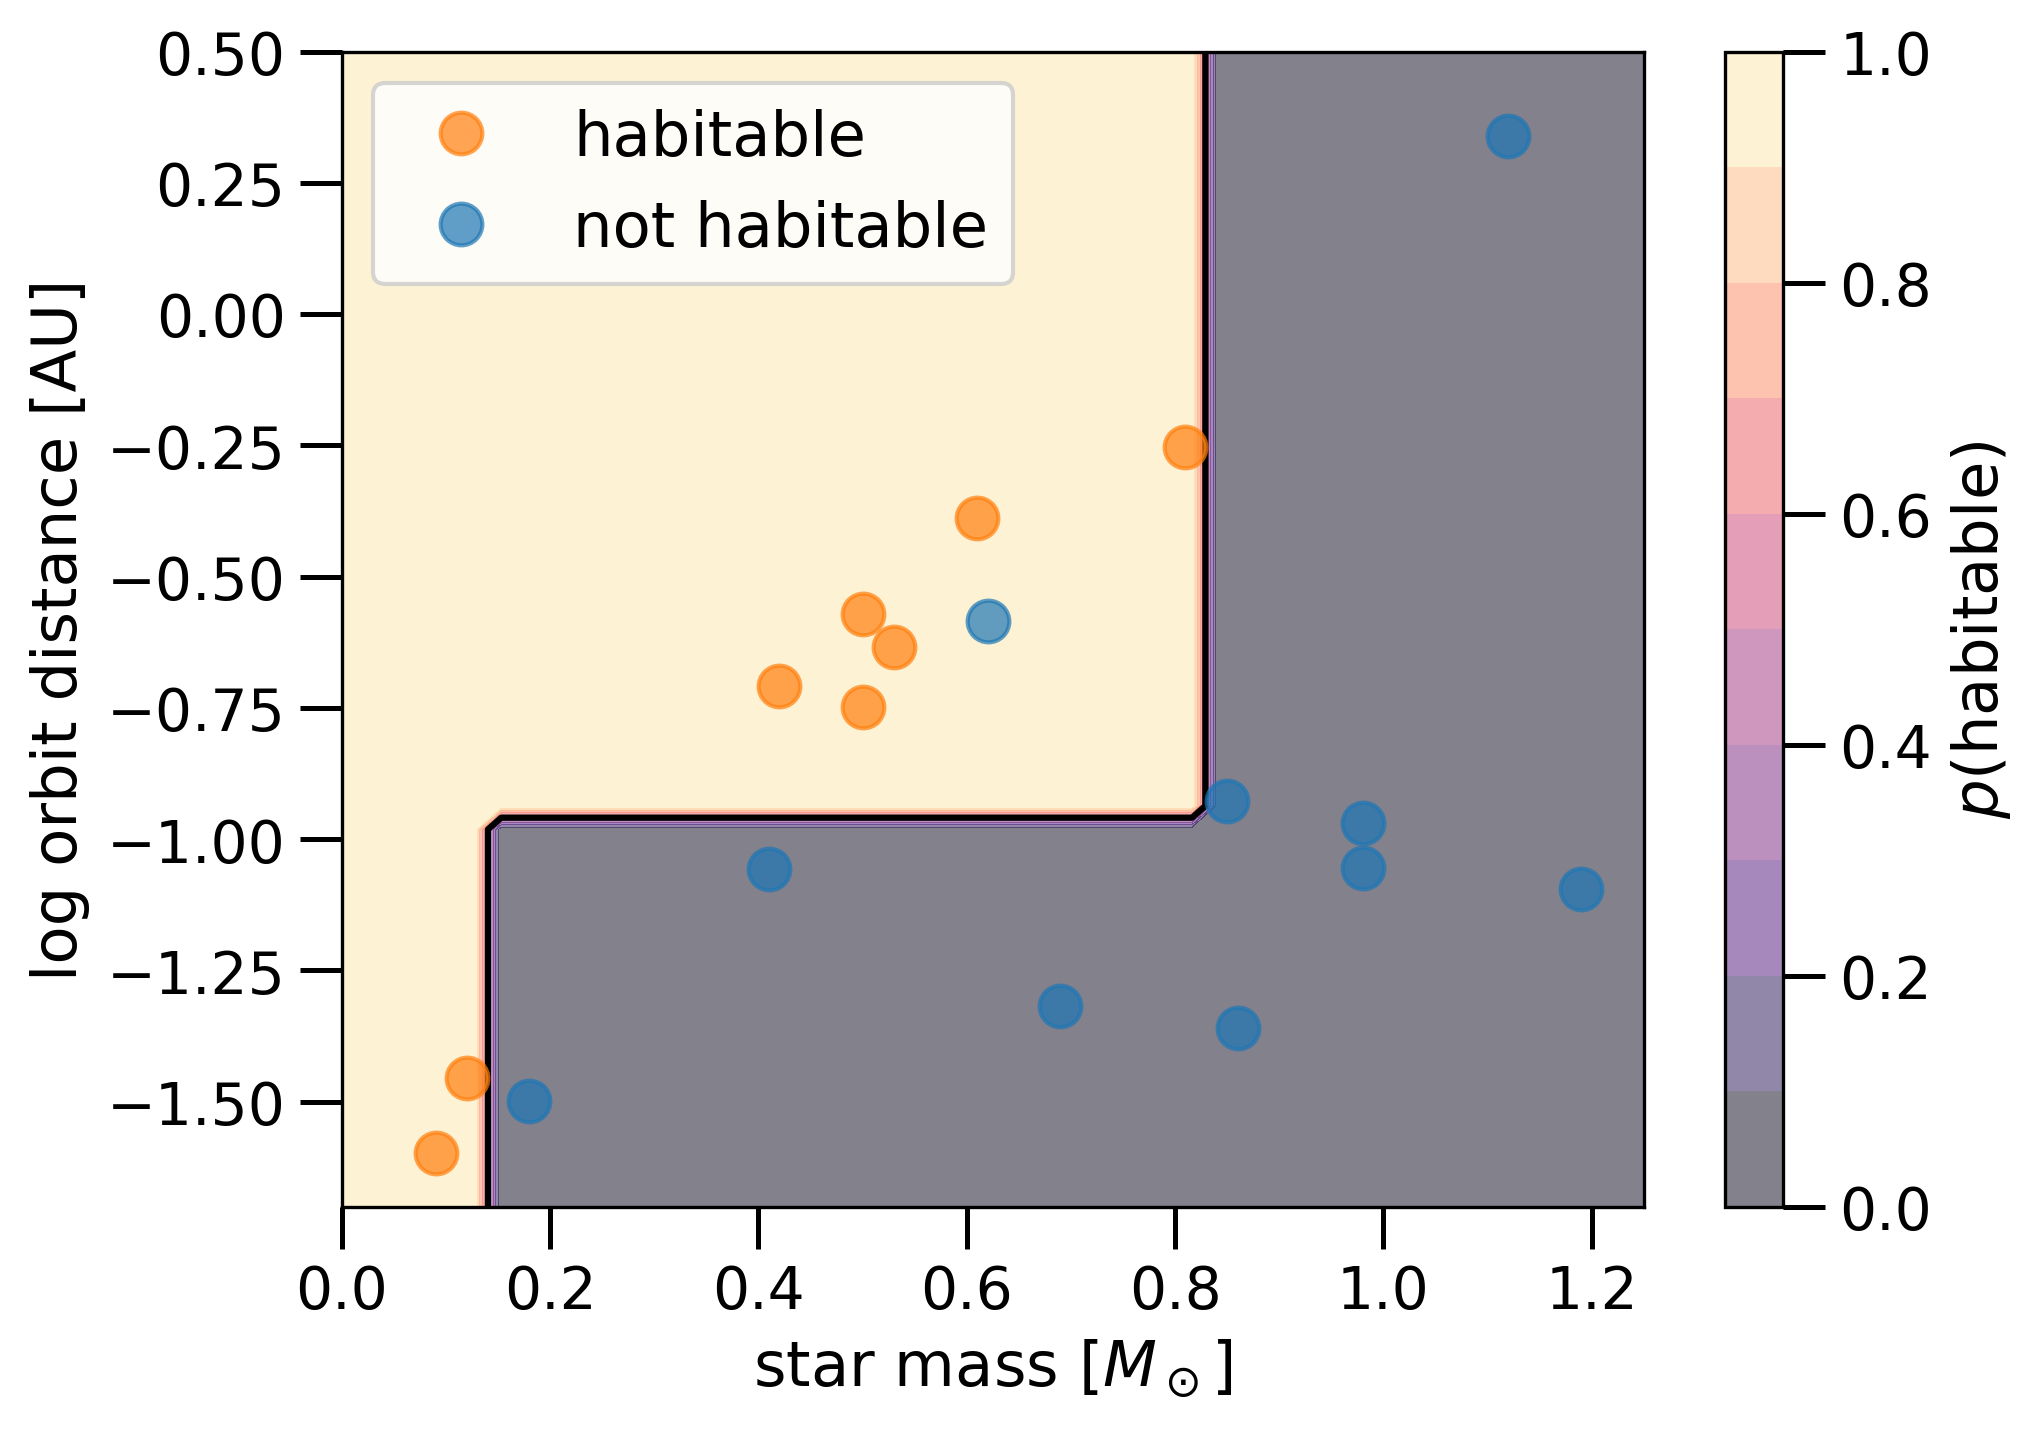

In [119]:
fig9 = plt.figure(figsize=(7,5))
cs=plt.contourf(mm,np.log10(dd),prob,cmap="magma",levels=np.linspace(0,1,11),alpha=0.5)
cbar = fig9.colorbar(cs)
cbar.set_label('$p$(habitable)',fontsize=15)
plt.contour(mm,np.log10(dd),prob,[0.5],colors='k')
plt.plot(LearningSet1['S_MASS'].iloc[habi],np.log10(LearningSet1['P_DISTANCE'].iloc[habi]),'o',c='C1',ms=10,alpha=0.7,label='habitable')
plt.plot(LearningSet1['S_MASS'].iloc[nohabi],np.log10(LearningSet1['P_DISTANCE'].iloc[nohabi]),'o',c='C0',ms=10,alpha=0.7,label='not habitable')
plt.xlabel('star mass [$M_\odot$]',fontsize=15)
plt.ylabel('log orbit distance [AU]',fontsize=15)
plt.legend(loc='best',fontsize=15)

### Our final exercise will consist of picking a different train/test split.

In [120]:
TrainSet2 = LearningSet1.iloc[5:,:] #we pick the first 5 objects for test, 5:18 for training
TestSet2 = LearningSet1.iloc[:5,:]

### Go through the motion again...

In [121]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'],axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

### And we are ready to fit the model again with our decision tree!
model = DecisionTreeClassifier(random_state=3)
model.fit(Xtrain2,ytrain2)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

### We can now visualize the new tree:

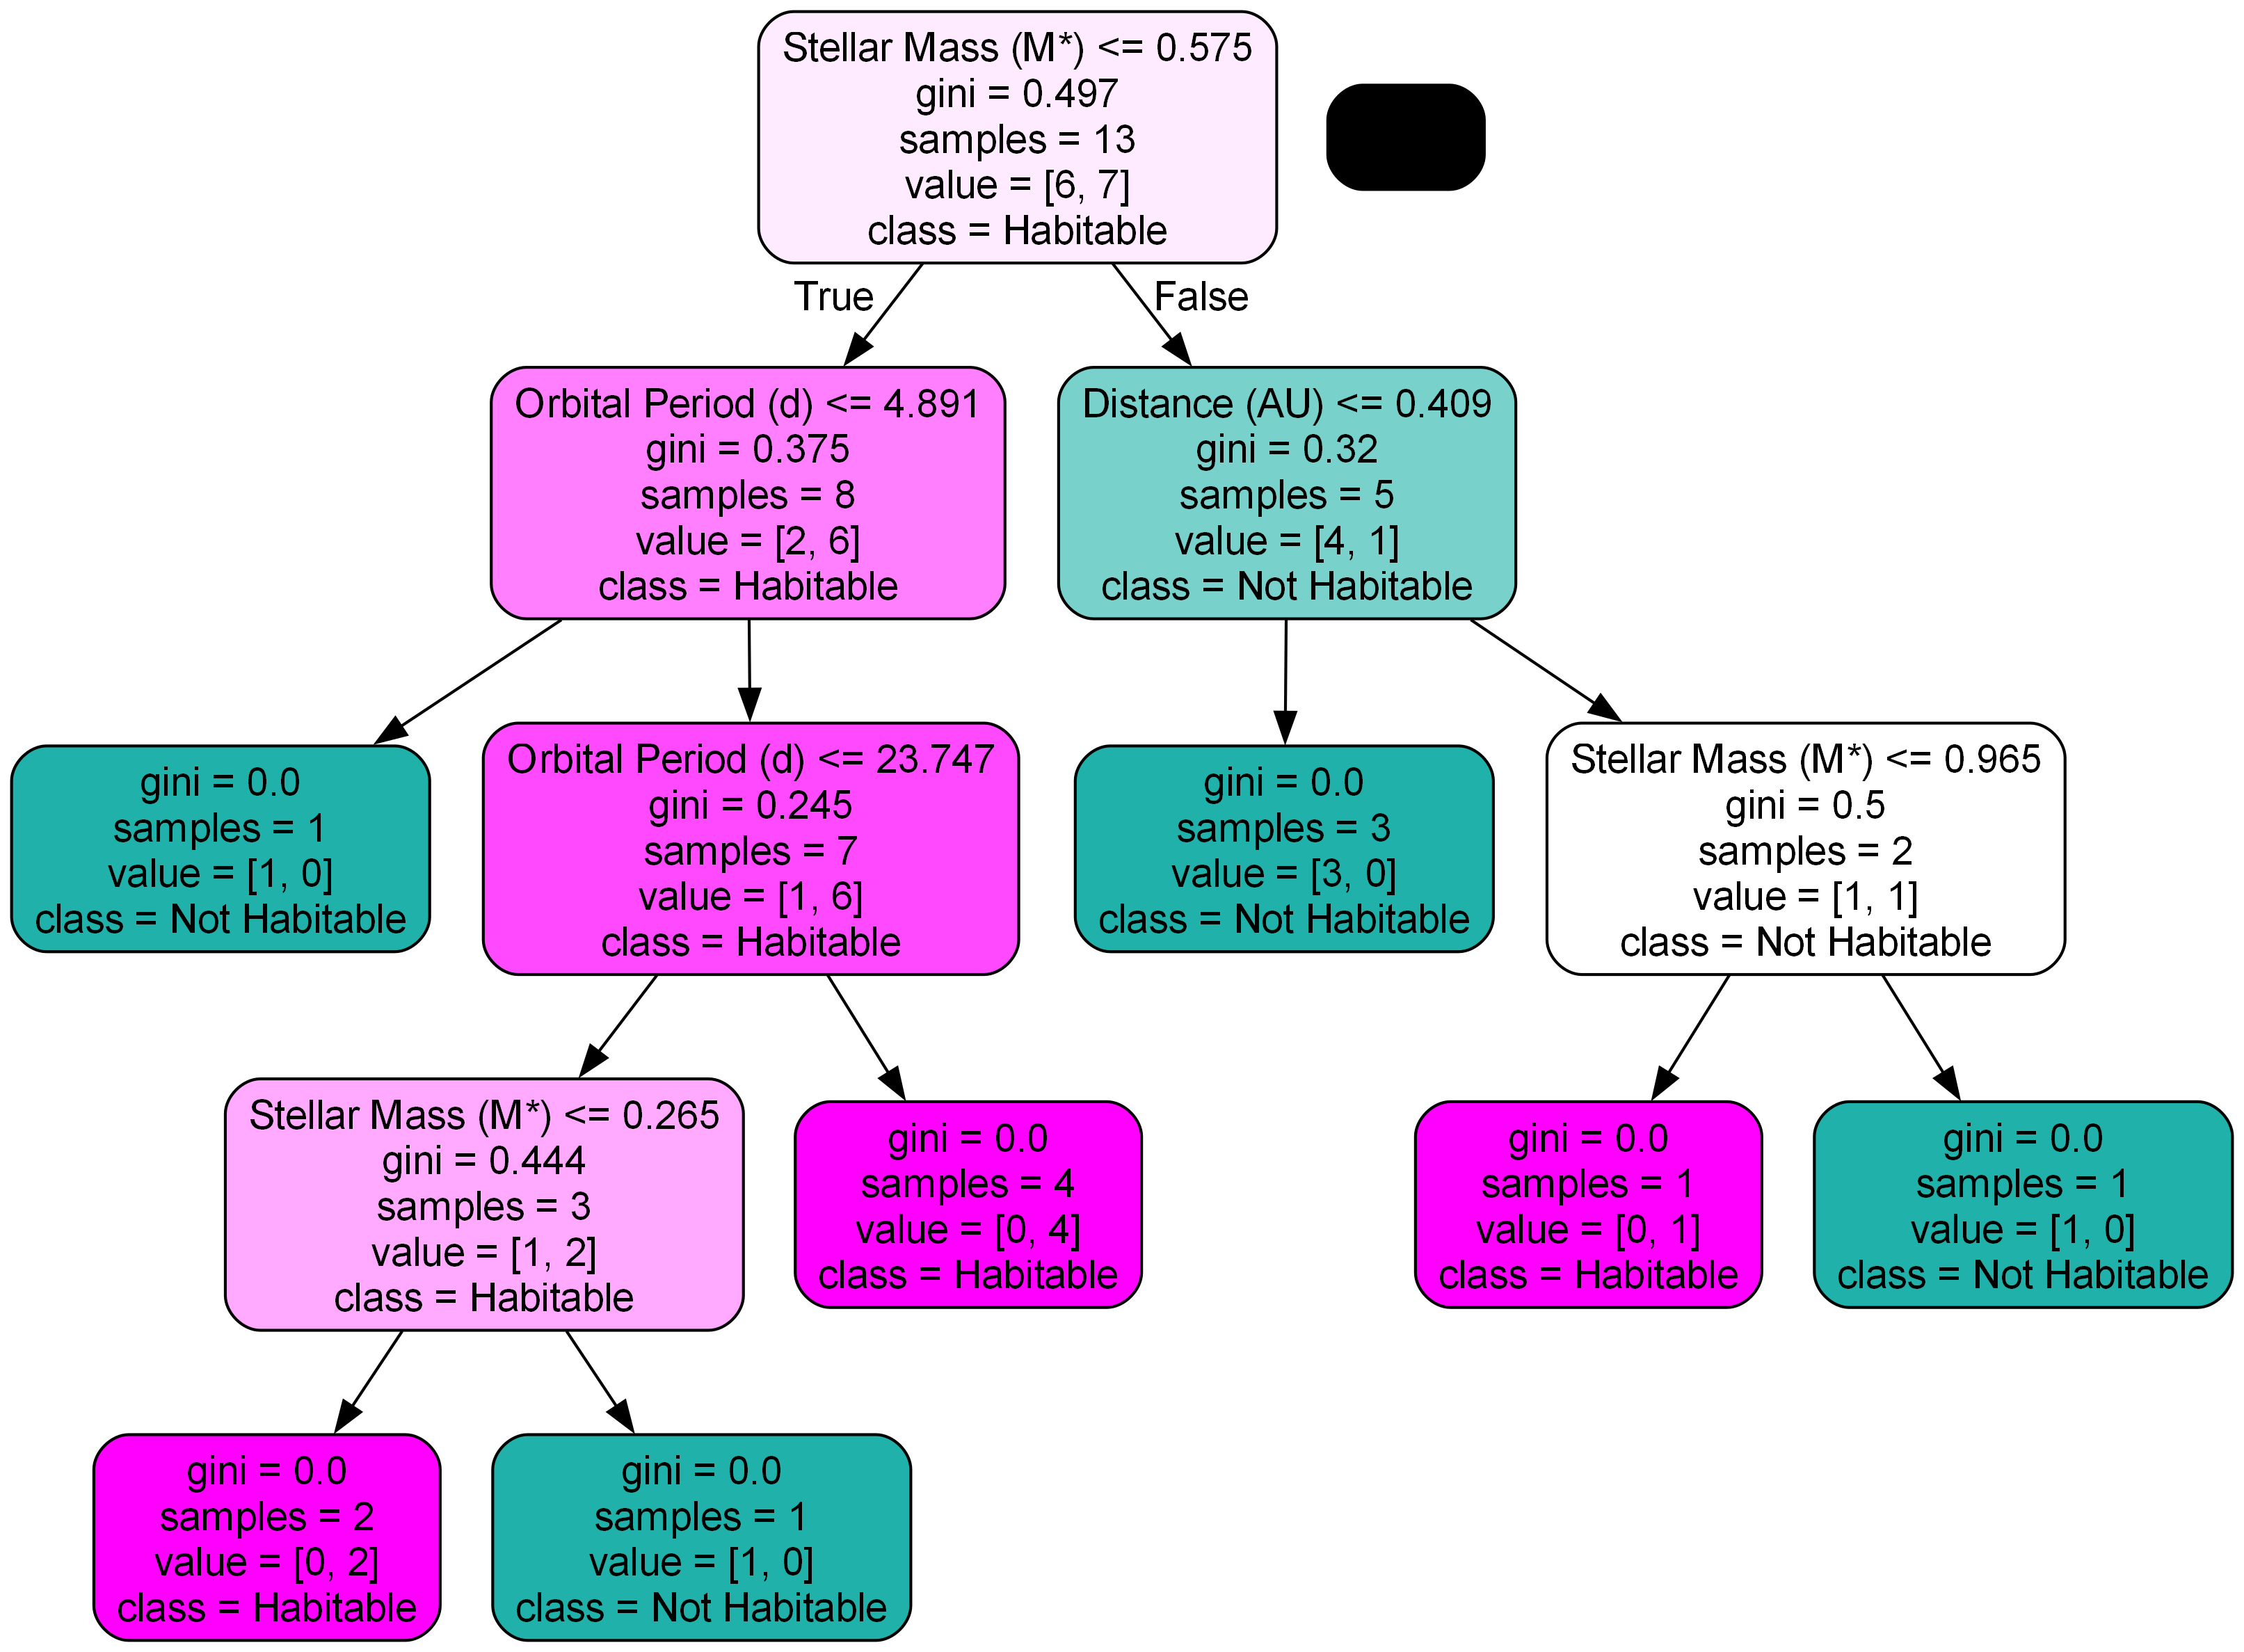

In [122]:
dot_data = StringIO()
export_graphviz(
            model,
            out_file =  dot_data,
            feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
            class_names = ['Not Habitable','Habitable'],
            filled = True,
rounded = True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label():
        values = [int(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [255 * v / sum(values) for v in values]
        
        values = [int(255 * v / sum(values)) for v in values]
            
        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha) #turn into hexadecimal
            color = '#20 B2 AA'+str(alpha)
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#FF 00 FF'+str(alpha)
        node.set_fillcolor(color)

graph.set_dpi('300')

Image(graph.create_png())

#Image(graph.write_png('Graph.png'))

### As you can see, this is quite different from the one we had before!

### Questions: 
    
- What is the accuracy (percentage of correct classifications) on the training set? 100%


- How about on the test set? 


In [123]:
metrics.accuracy_score(ytest2, model.predict(Xtest2))

1.0

In [124]:
mat = metrics.confusion_matrix(ytest2, model.predict(Xtest2))

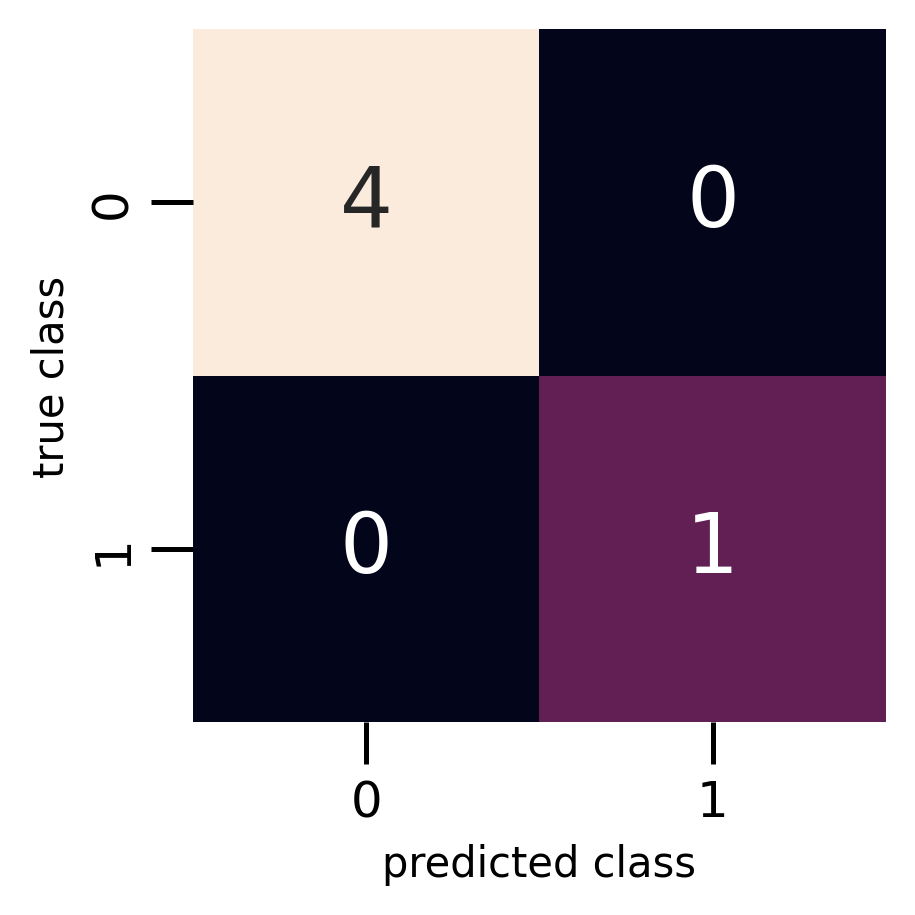

In [125]:
fig10 = plt.figure(figsize=(3,3))
sns.heatmap(mat, square=True, annot=True, cbar=False)
plt.xlabel('predicted class',fontsize=10)
plt.ylabel('true class',fontsize=10)
#plt.title('Gaussian Naive Bayes classified')
plt.tick_params(labelsize=12)

### Let's draw some conclusions together.

- Strengths of DT algorithm? Easy, fast, interpretable!

- Limitations? It is easy to overfit (get too affectionate to the training set and absorb noise); you can only split along one feature at a time; requires feature engineering if you want to consider combinations of features.

- Possible concerns? This data set is probably too small for conclusions; the fact that test scores fluctuate so much in response to different train/test set splits is an indication of this. Additionally, would the Earth be classified as habitable by either of these trees?